# Análisis de Churn Bancario con Regresión Logística

### En este análisis estudiamos el fenómeno de churn bancario, es decir, la salida de clientes del banco, utilizando análisis exploratorio de datos y un modelo de Regresión Logística.
### El objetivo es identificar qué factores influyen más en que un cliente se vaya, para ayudar al banco a tomar decisiones estratégicas y mejorar la retención.

In [1]:
## 1. Comprensión del Problema y Análisis Exploratorio

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Configuración de estilo
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [3]:
# Cargar el dataset
df = pd.read_csv('Churn_Modelling.csv')

### El dataset contiene 10,000 clientes, con variables demográficas (edad, género, país), financieras (balance, productos, salario estimado) y la variable objetivo Exited, que indica si el cliente abandonó o no.

### Puntos clave:

#### No hay valores nulos, lo que facilita el trabajo de modelado.

### La variable objetivo está desbalanceada:

### 80% clientes permanecen.
### 20% se van.

#### Esto indica que el churn es un evento menos frecuente pero importante, y condiciona el rendimiento de los modelos.

### ¿Qué es el Churn Bancario?
#### El churn bancario (o abandono de clientes) se refiere a cuando un cliente decide dejar el banco y cancelar sus servicios. 
#### Es un problema crítico porque:
#### - Es más costoso adquirir nuevos clientes que retener los existentes
#### - Los clientes que se van pueden afectar la reputación del banco
#### - La pérdida de ingresos recurrentes impacta la rentabilidad

In [4]:
# Exploración inicial del dataset

print("=== INFORMACIÓN BÁSICA DEL DATASET ===")
print(f"Dimensiones del dataset: {df.shape}")
print(f"\nPrimeras 5 filas:")
display(df.head())

print(f"\nInformación del dataset:")
df.info()

print(f"\nEstadísticas descriptivas:")
display(df.describe())

=== INFORMACIÓN BÁSICA DEL DATASET ===
Dimensiones del dataset: (10000, 14)

Primeras 5 filas:


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0



Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB

Estadísticas descriptivas:


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [5]:
# Análisis de valores nulos
print("=== VALORES NULOS ===")
print(df.isnull().sum())

=== VALORES NULOS ===
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


=== DISTRIBUCIÓN DEL CHURN ===
Exited
0    7963
1    2037
Name: count, dtype: int64


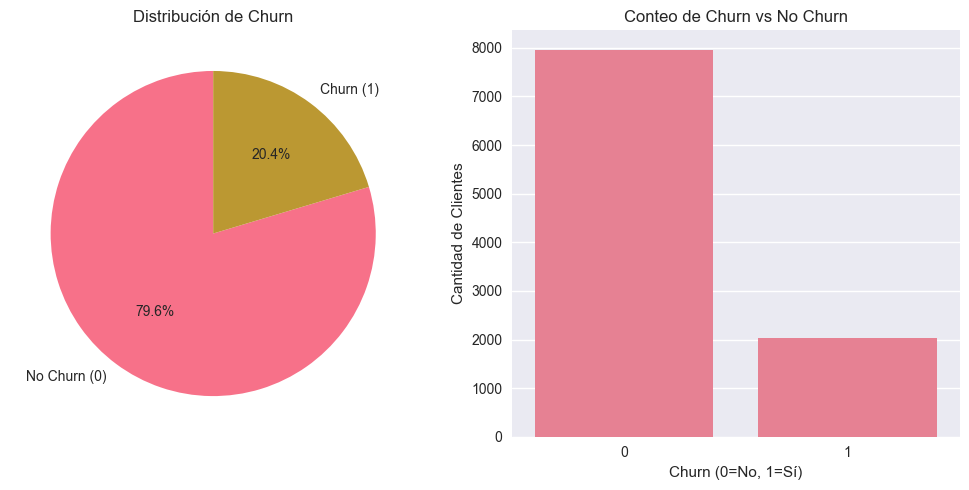

Porcentaje de churn: 20.37%


In [6]:
# Distribución de la variable objetivo (Exited)
print("=== DISTRIBUCIÓN DEL CHURN ===")
churn_dist = df['Exited'].value_counts()
print(churn_dist)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.pie(churn_dist.values, labels=['No Churn (0)', 'Churn (1)'], autopct='%1.1f%%', startangle=90)
plt.title('Distribución de Churn')

plt.subplot(1, 2, 2)
sns.countplot(data=df, x='Exited')
plt.title('Conteo de Churn vs No Churn')
plt.xlabel('Churn (0=No, 1=Sí)')
plt.ylabel('Cantidad de Clientes')

plt.tight_layout()
plt.show()

print(f"Porcentaje de churn: {churn_dist[1]/len(df)*100:.2f}%")


### Distribución de la variable objetivo

#### Se presenta un gráfico comparando clientes que se quedan vs. los que se van.

### Insights:

#### La mayoría de los clientes permanecen en el banco.

#### Existe un churn cercano al 20%, lo cual representa un riesgo significativo.

#### El desbalance implica que deben evaluarse métricas más allá de la exactitud.

=== ANÁLISIS DEMOGRÁFICO ===


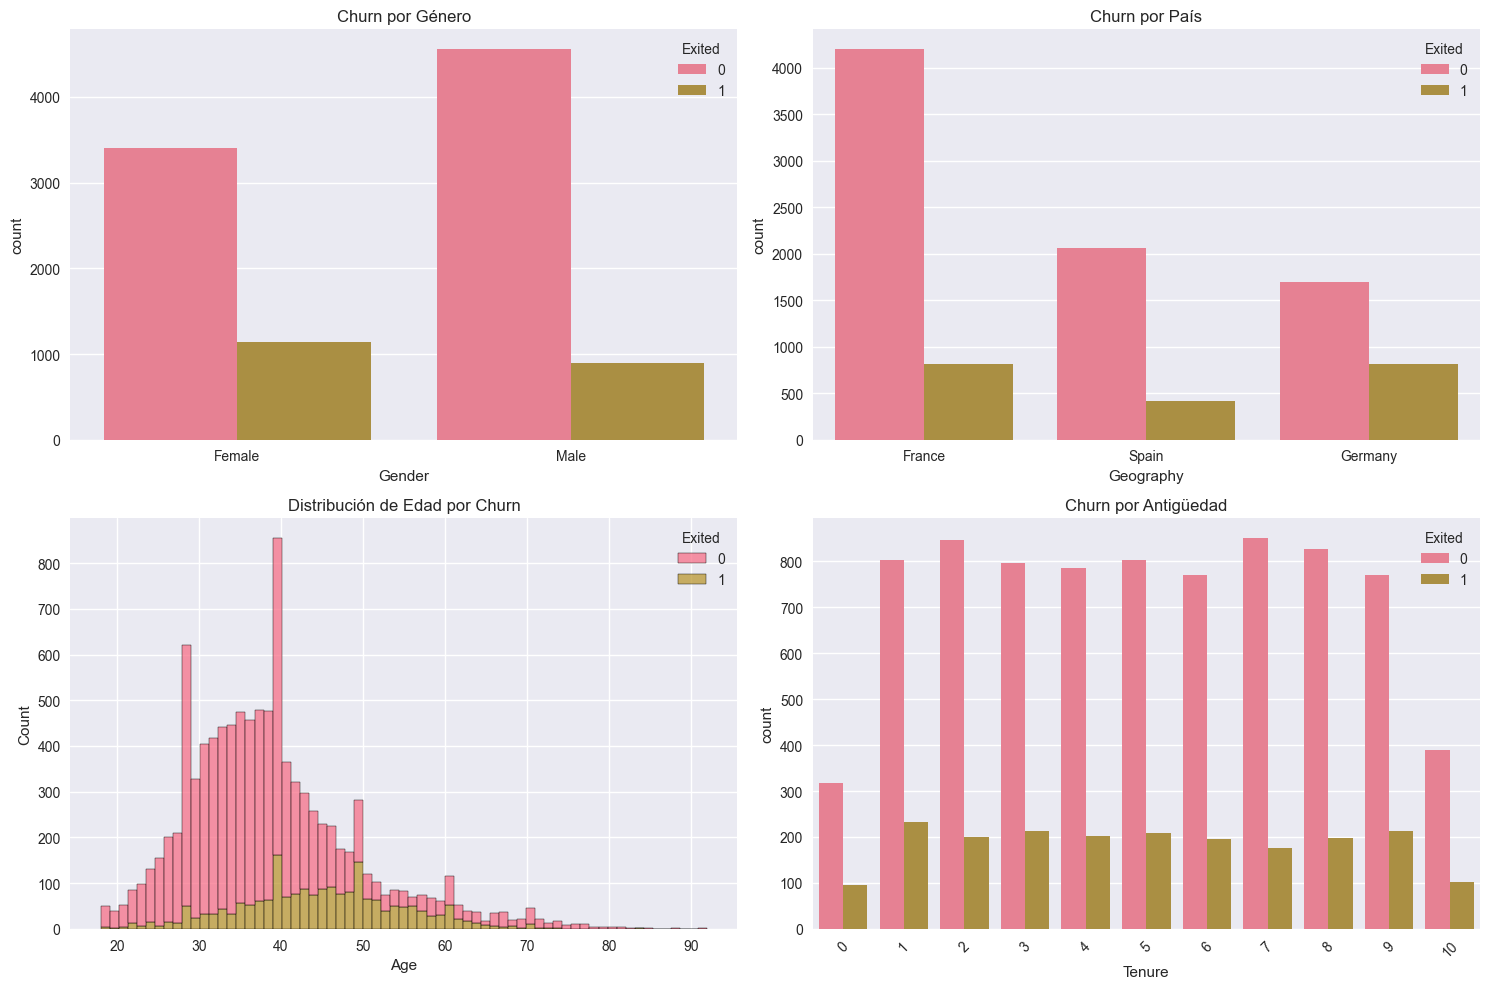

In [7]:
# Análisis de variables demográficas
print("=== ANÁLISIS DEMOGRÁFICO ===")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Género
gender_churn = pd.crosstab(df['Gender'], df['Exited'])
sns.countplot(data=df, x='Gender', hue='Exited', ax=axes[0,0])
axes[0,0].set_title('Churn por Género')

# Geografía
geo_churn = pd.crosstab(df['Geography'], df['Exited'])
sns.countplot(data=df, x='Geography', hue='Exited', ax=axes[0,1])
axes[0,1].set_title('Churn por País')

# Edad
sns.histplot(data=df, x='Age', hue='Exited', multiple="stack", ax=axes[1,0])
axes[1,0].set_title('Distribución de Edad por Churn')

# Antigüedad (Tenure)
tenure_churn = pd.crosstab(df['Tenure'], df['Exited'])
sns.countplot(data=df, x='Tenure', hue='Exited', ax=axes[1,1])
axes[1,1].set_title('Churn por Antigüedad')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Análisis demográfico

#### Se analizan variables como género, edad y país.

### Resultados relevantes:

### Edad:
#### El churn aumenta con la edad; los clientes que se van tienden a ser mayores.

### Género:
#### Las mujeres tienen una tasa de abandono ligeramente mayor, aunque no es una diferencia notable.

### País:
#### Aquí aparece una diferencia marcada:

### Alemania concentra la mayor proporción de abandono.

### Francia y España muestran comportamientos más estables.
#####           → El contexto geográfico influye fuertemente.

=== ANÁLISIS FINANCIERO ===


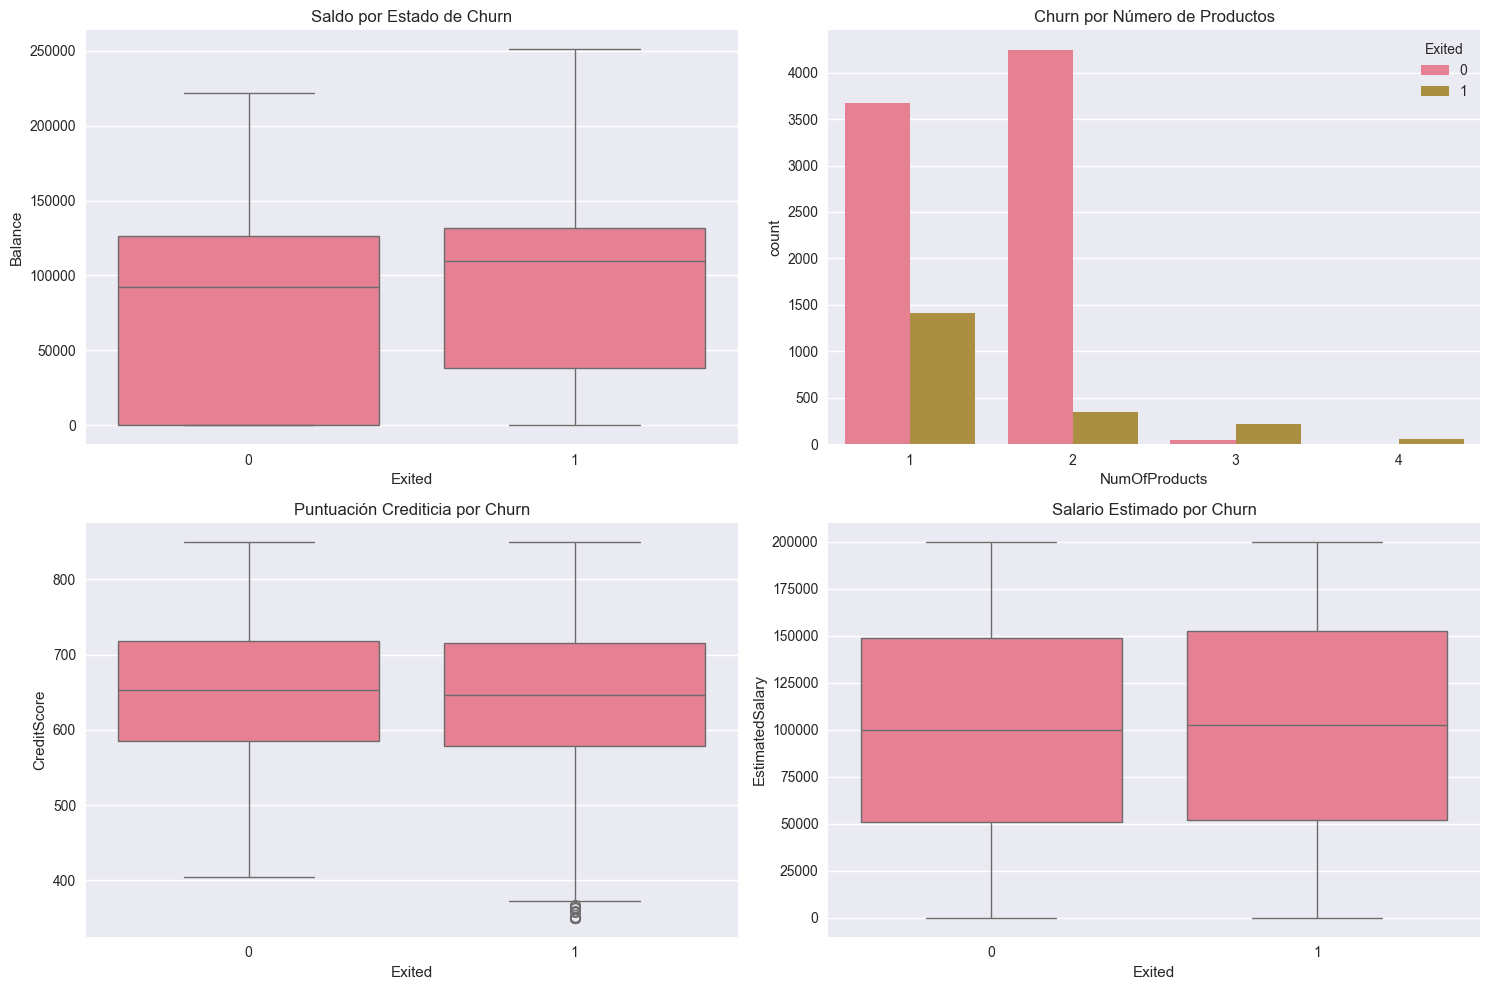

In [8]:
# Análisis de variables financieras
print("=== ANÁLISIS FINANCIERO ===")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Saldo promedio
sns.boxplot(data=df, x='Exited', y='Balance', ax=axes[0,0])
axes[0,0].set_title('Saldo por Estado de Churn')

# Número de productos
product_churn = pd.crosstab(df['NumOfProducts'], df['Exited'])
sns.countplot(data=df, x='NumOfProducts', hue='Exited', ax=axes[0,1])
axes[0,1].set_title('Churn por Número de Productos')

# Puntuación crediticia
sns.boxplot(data=df, x='Exited', y='CreditScore', ax=axes[1,0])
axes[1,0].set_title('Puntuación Crediticia por Churn')

# Salario estimado
sns.boxplot(data=df, x='Exited', y='EstimatedSalary', ax=axes[1,1])
axes[1,1].set_title('Salario Estimado por Churn')

plt.tight_layout()
plt.show()

 ### Variables financieras

#### Aquí unificamos lo mejor de ambas respuestas:

### Balance:

#### El churn es más alto en clientes con balances muy altos o con balances cercanos a cero. Esto sugiere dos perfiles distintos:

#### Clientes con altos recursos que podrían estar migrando a bancos con mejores condiciones.

#### Clientes con poco uso del banco o baja vinculación.

### Número de productos:

#### Los clientes con tres o más productos muestran mayor propensión a irse.
##### → Puede indicar sobreventa, saturación o productos que no generan satisfacción.

### Actividad del cliente:

### Es uno de los factores más determinantes.
#### Los clientes inactivos tienen mucha mayor tendencia al churn.
##### → La inactividad es un claro indicador de desenganche.

### Tarjeta de crédito:

#### Tener o no tarjeta apenas afecta el churn.
##### → Variable poco relevante.

=== MATRIZ DE CORRELACIONES ===


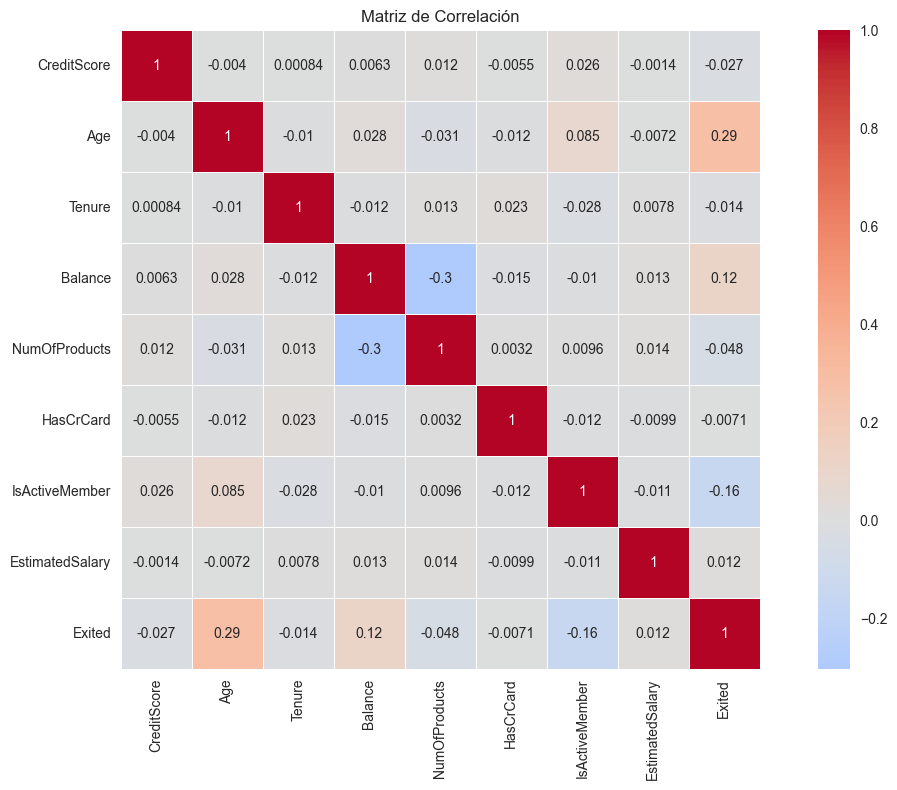

In [9]:
# Análisis de correlaciones
print("=== MATRIZ DE CORRELACIONES ===")

# Seleccionar solo variables numéricas
numeric_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 
                'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

plt.figure(figsize=(12, 8))
correlation_matrix = df[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
           square=True, linewidths=0.5)
plt.title('Matriz de Correlación')
plt.tight_layout()
plt.show()

## 2. Preparación de Datos para Regresión Logística

In [10]:
# Copiar el dataset para preparación
df_processed = df.copy()

# Eliminar columnas no relevantes para el modelo
df_processed = df_processed.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

print("Dataset después de eliminar columnas irrelevantes:")
print(f"Dimensiones: {df_processed.shape}")

Dataset después de eliminar columnas irrelevantes:
Dimensiones: (10000, 11)


In [11]:
# Encoding de variables categóricas
print("=== ENCODING DE VARIABLES CATEGÓRICAS ===")

# Label Encoding para Gender
le_gender = LabelEncoder()
df_processed['Gender'] = le_gender.fit_transform(df_processed['Gender'])
print(f"Gender encoding: {dict(zip(le_gender.classes_, le_gender.transform(le_gender.classes_)))}")

# One-Hot Encoding para Geography
df_processed = pd.get_dummies(df_processed, columns=['Geography'], prefix='Geo', drop_first=True)

print("\nDataset después del encoding:")
print(df_processed.head())

=== ENCODING DE VARIABLES CATEGÓRICAS ===
Gender encoding: {'Female': np.int64(0), 'Male': np.int64(1)}

Dataset después del encoding:
   CreditScore  Gender  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
0          619       0   42       2       0.00              1          1   
1          608       0   41       1   83807.86              1          0   
2          502       0   42       8  159660.80              3          1   
3          699       0   39       1       0.00              2          0   
4          850       0   43       2  125510.82              1          1   

   IsActiveMember  EstimatedSalary  Exited  Geo_Germany  Geo_Spain  
0               1        101348.88       1        False      False  
1               1        112542.58       0        False       True  
2               0        113931.57       1        False      False  
3               0         93826.63       0        False      False  
4               1         79084.10       0        False       T

In [12]:
# Verificar balance de clases
print("=== BALANCE DE CLASES ===")
target_dist = df_processed['Exited'].value_counts()
print(target_dist)
print(f"\nProporción: {target_dist[0]}:{target_dist[1]} ({target_dist[1]/len(df_processed)*100:.2f}% de churn)")

=== BALANCE DE CLASES ===
Exited
0    7963
1    2037
Name: count, dtype: int64

Proporción: 7963:2037 (20.37% de churn)


In [13]:
# Separar características y variable objetivo
X = df_processed.drop('Exited', axis=1)
y = df_processed['Exited']

print("Características (X):")
print(X.columns.tolist())
print(f"\nDimensiones de X: {X.shape}")

Características (X):
['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geo_Germany', 'Geo_Spain']

Dimensiones de X: (10000, 11)


In [14]:
# Escalamiento de variables numéricas
scaler = StandardScaler()

# Columnas a escalar (excluyendo las binarias y dummies)
cols_to_scale = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']

X_scaled = X.copy()
X_scaled[cols_to_scale] = scaler.fit_transform(X[cols_to_scale])

print("=== DATOS ESCALADOS ===")
print("Primeras 5 filas de características escaladas:")
display(X_scaled.head())

=== DATOS ESCALADOS ===
Primeras 5 filas de características escaladas:


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geo_Germany,Geo_Spain
0,-0.326221,0,0.293517,-1.041760,-1.225848,1,1,1,0.021886,False,False
1,-0.440036,0,0.198164,-1.387538,0.117350,1,0,1,0.216534,False,True
2,-1.536794,0,0.293517,1.032908,1.333053,3,1,0,0.240687,False,False
3,0.501521,0,0.007457,-1.387538,-1.225848,2,0,0,-0.108918,False,False
4,2.063884,0,0.388871,-1.041760,0.785728,1,1,1,-0.365276,False,True


In [15]:
# Split en train y test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("=== DIVISIÓN TRAIN-TEST ===")
print(f"Tamaño del conjunto de entrenamiento: {X_train.shape}")
print(f"Tamaño del conjunto de prueba: {X_test.shape}")
print(f"\nDistribución en train: {y_train.value_counts().to_dict()}")
print(f"Distribución en test: {y_test.value_counts().to_dict()}")

=== DIVISIÓN TRAIN-TEST ===
Tamaño del conjunto de entrenamiento: (8000, 11)
Tamaño del conjunto de prueba: (2000, 11)

Distribución en train: {0: 6370, 1: 1630}
Distribución en test: {0: 1593, 1: 407}


=== ANÁLISIS DE MULTICOLINEALIDAD ===


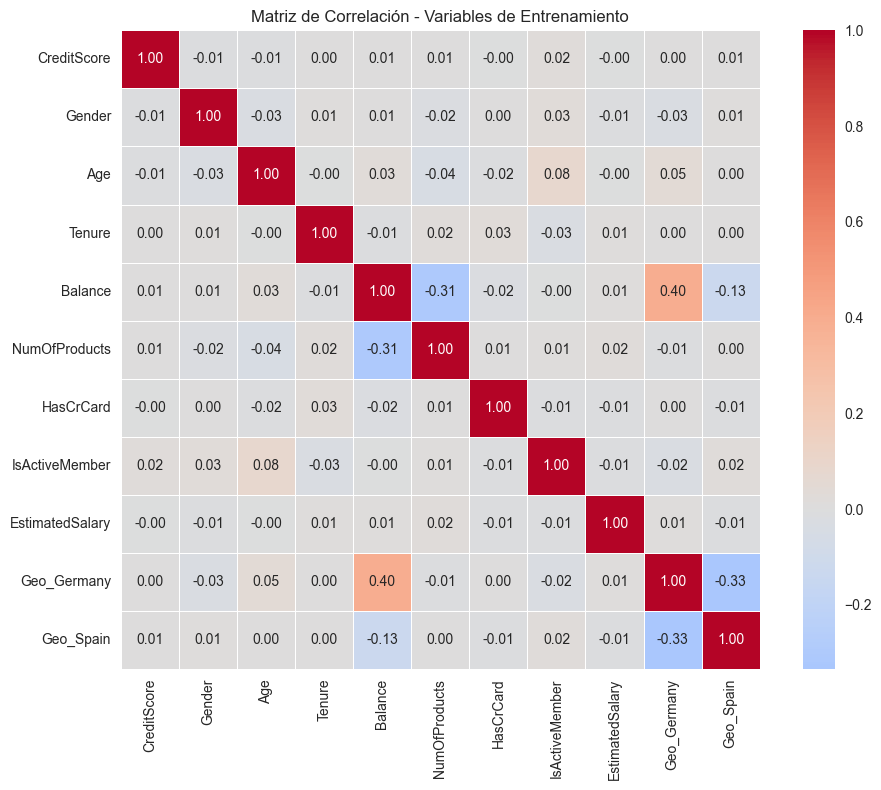

No se encontraron correlaciones altas (>0.7)


In [16]:
# Verificar multicolinealidad
print("=== ANÁLISIS DE MULTICOLINEALIDAD ===")

plt.figure(figsize=(10, 8))
corr_matrix_train = X_train.corr()
sns.heatmap(corr_matrix_train, annot=True, cmap='coolwarm', center=0,
           square=True, linewidths=0.5, fmt='.2f')
plt.title('Matriz de Correlación - Variables de Entrenamiento')
plt.tight_layout()
plt.show()

# Identificar correlaciones altas
high_corr = []
for i in range(len(corr_matrix_train.columns)):
    for j in range(i+1, len(corr_matrix_train.columns)):
        if abs(corr_matrix_train.iloc[i, j]) > 0.7:
            high_corr.append((
                corr_matrix_train.columns[i],
                corr_matrix_train.columns[j],
                corr_matrix_train.iloc[i, j]
            ))

if high_corr:
    print("Correlaciones altas encontradas:")
    for corr in high_corr:
        print(f"  {corr[0]} - {corr[1]}: {corr[2]:.3f}")
else:
    print("No se encontraron correlaciones altas (>0.7)")

## 3. Implementación de Regresión Logística

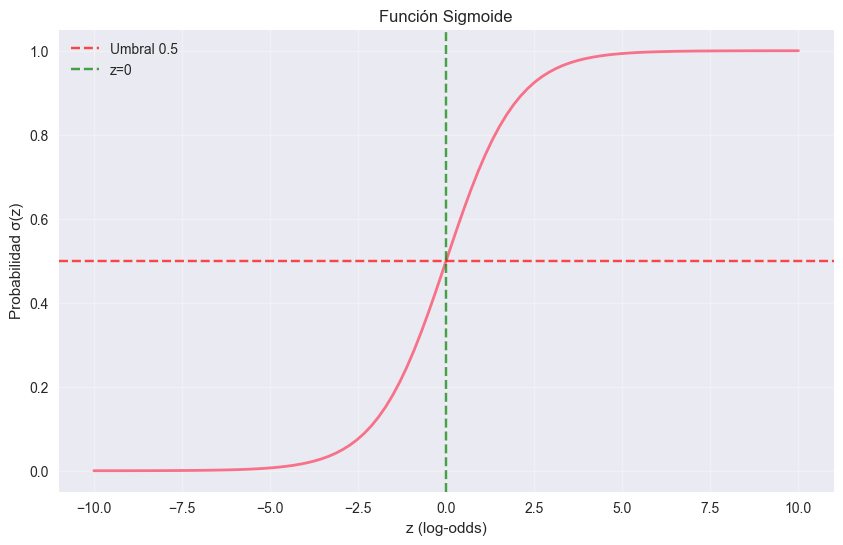

In [17]:
# Función sigmoide (para entender el concepto)
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Visualizar función sigmoide
z = np.linspace(-10, 10, 100)
sigmoid_values = sigmoid(z)

plt.figure(figsize=(10, 6))
plt.plot(z, sigmoid_values, linewidth=2)
plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.7, label='Umbral 0.5')
plt.axvline(x=0, color='green', linestyle='--', alpha=0.7, label='z=0')
plt.xlabel('z (log-odds)')
plt.ylabel('Probabilidad σ(z)')
plt.title('Función Sigmoide')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [18]:
# Entrenar modelo de regresión logística
print("=== ENTRENAMIENTO DEL MODELO ===")

log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train, y_train)

print("Modelo entrenado exitosamente!")
print(f"Número de iteraciones: {log_reg.n_iter_[0]}")

=== ENTRENAMIENTO DEL MODELO ===
Modelo entrenado exitosamente!
Número de iteraciones: 17


In [19]:
# Coeficientes del modelo
print("=== COEFICIENTES DEL MODELO ===")

feature_names = X_train.columns.tolist()
coefficients = log_reg.coef_[0]

coef_df = pd.DataFrame({
    'Característica': feature_names,
    'Coeficiente': coefficients,
    'Odds_Ratio': np.exp(coefficients)
}).sort_values('Coeficiente', ascending=False)

display(coef_df)

=== COEFICIENTES DEL MODELO ===


,Característica,Coeficiente,Odds_Ratio
9,Geo_Germany,0.819569,2.269521
2,Age,0.735326,2.086162
4,Balance,0.161483,1.175252
8,EstimatedSalary,0.047960,1.049129
10,Geo_Spain,0.042054,1.042951
3,Tenure,-0.020118,0.980083
6,HasCrCard,-0.071056,0.931409
0,CreditScore,-0.086039,0.917559
5,NumOfProducts,-0.120164,0.886775
1,Gender,-0.523261,0.592585


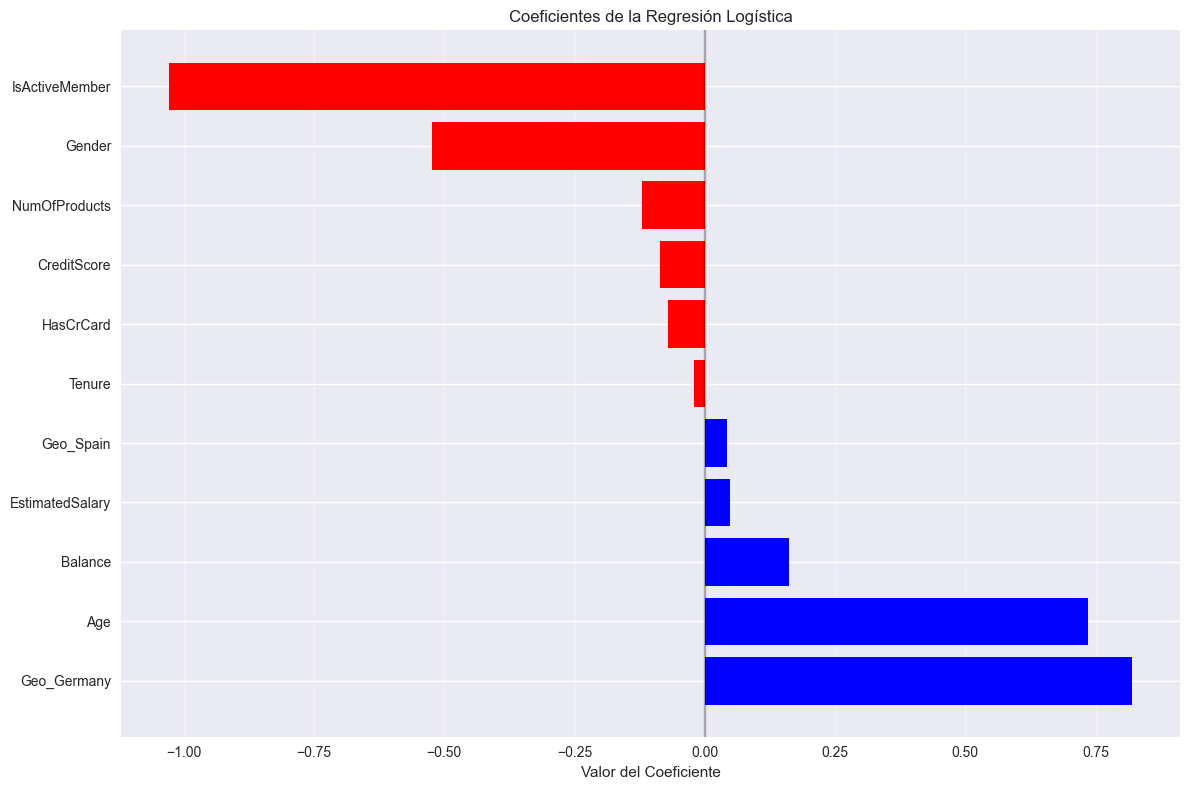

In [20]:
# Visualizar coeficientes
plt.figure(figsize=(12, 8))
colors = ['red' if x < 0 else 'blue' for x in coef_df['Coeficiente']]
plt.barh(coef_df['Característica'], coef_df['Coeficiente'], color=colors)
plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
plt.xlabel('Valor del Coeficiente')
plt.title('Coeficientes de la Regresión Logística')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [21]:
# Interpretación de odds ratios
print("=== INTERPRETACIÓN DE ODDS RATIOS ===")
print("Odds Ratio > 1: Aumenta la probabilidad de churn")
print("Odds Ratio < 1: Disminuye la probabilidad de churn")
print("Odds Ratio = 1: No tiene efecto\n")

for _, row in coef_df.iterrows():
    effect = "AUMENTA" if row['Odds_Ratio'] > 1 else "DISMINUYE"
    print(f"{row['Característica']:20} | Odds Ratio: {row['Odds_Ratio']:7.3f} | {effect} el churn")

=== INTERPRETACIÓN DE ODDS RATIOS ===
Odds Ratio > 1: Aumenta la probabilidad de churn
Odds Ratio < 1: Disminuye la probabilidad de churn
Odds Ratio = 1: No tiene efecto

Geo_Germany          | Odds Ratio:   2.270 | AUMENTA el churn
Age                  | Odds Ratio:   2.086 | AUMENTA el churn
Balance              | Odds Ratio:   1.175 | AUMENTA el churn
EstimatedSalary      | Odds Ratio:   1.049 | AUMENTA el churn
Geo_Spain            | Odds Ratio:   1.043 | AUMENTA el churn
Tenure               | Odds Ratio:   0.980 | DISMINUYE el churn
HasCrCard            | Odds Ratio:   0.931 | DISMINUYE el churn
CreditScore          | Odds Ratio:   0.918 | DISMINUYE el churn
NumOfProducts        | Odds Ratio:   0.887 | DISMINUYE el churn
Gender               | Odds Ratio:   0.593 | DISMINUYE el churn
IsActiveMember       | Odds Ratio:   0.358 | DISMINUYE el churn


### Regresión Logística

#### El modelo se entrena para predecir qué clientes podrían abandonar.

### Puntos importantes del modelo:

### El modelo captura bien a los clientes que permanecen, debido al desbalance.

### Le cuesta más identificar a los clientes que se van, algo esperable con este tipo de problemas.

#### Las variables más influyentes coinciden con el EDA:

#### - Edad

#### - País

#### - Actividad

#### - Número de productos
##### → Buena coherencia entre el análisis exploratorio y el modelo predictivo.

## 4. Evaluación del Modelo

In [22]:
# Predicciones
y_pred = log_reg.predict(X_test)
y_pred_proba = log_reg.predict_proba(X_test)[:, 1]

=== MATRIZ DE CONFUSIÓN ===


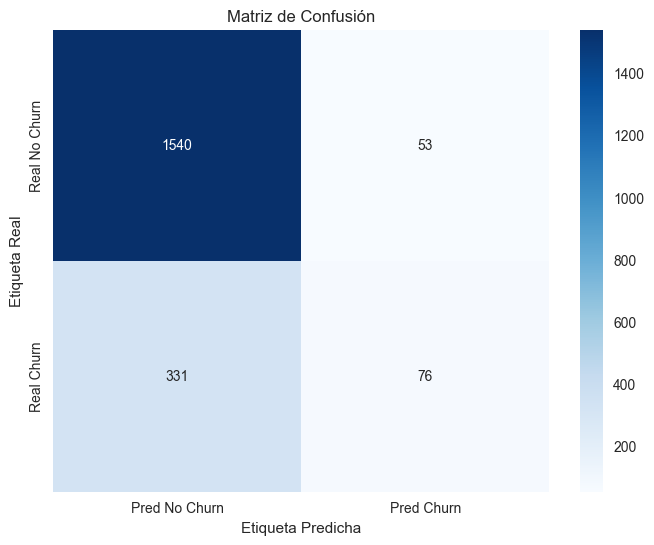

In [23]:
# Matriz de confusión
print("=== MATRIZ DE CONFUSIÓN ===")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
           xticklabels=['Pred No Churn', 'Pred Churn'],
           yticklabels=['Real No Churn', 'Real Churn'])
plt.title('Matriz de Confusión')
plt.ylabel('Etiqueta Real')
plt.xlabel('Etiqueta Predicha')
plt.show()


In [24]:
# Métricas de clasificación
print("=== MÉTRICAS DE CLASIFICACIÓN ===")

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Exactitud (Accuracy): {accuracy:.4f}")
print(f"Precisión: {precision:.4f}")
print(f"Sensibilidad (Recall): {recall:.4f}")
print(f"Puntuación F1: {f1:.4f}")

print("\nReporte de clasificación detallado:")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

=== MÉTRICAS DE CLASIFICACIÓN ===
Exactitud (Accuracy): 0.8080
Precisión: 0.5891
Sensibilidad (Recall): 0.1867
Puntuación F1: 0.2836

Reporte de clasificación detallado:
              precision    recall  f1-score   support

    No Churn       0.82      0.97      0.89      1593
       Churn       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



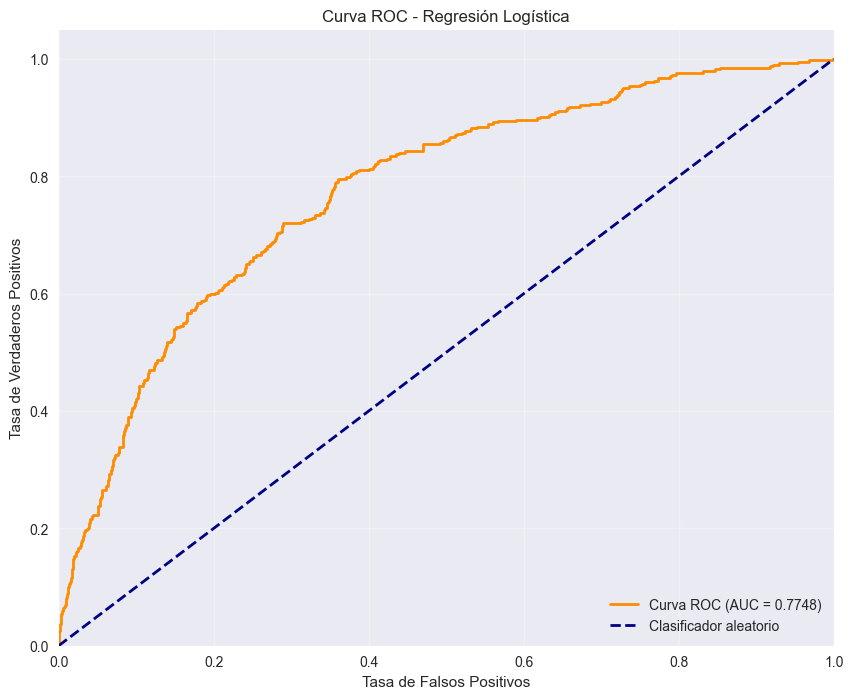

AUC Score: 0.7748


In [25]:
# Curva ROC y AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Clasificador aleatorio')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC - Regresión Logística')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

print(f"AUC Score: {roc_auc:.4f}")

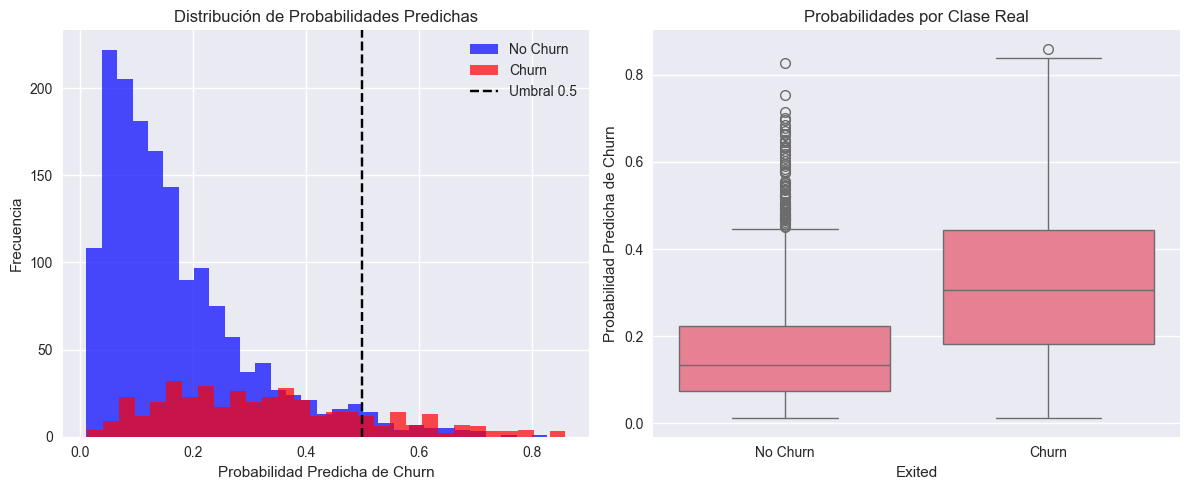

In [26]:
# Análisis de probabilidades predichas
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(y_pred_proba[y_test == 0], bins=30, alpha=0.7, label='No Churn', color='blue')
plt.hist(y_pred_proba[y_test == 1], bins=30, alpha=0.7, label='Churn', color='red')
plt.axvline(x=0.5, color='black', linestyle='--', label='Umbral 0.5')
plt.xlabel('Probabilidad Predicha de Churn')
plt.ylabel('Frecuencia')
plt.title('Distribución de Probabilidades Predichas')
plt.legend()

plt.subplot(1, 2, 2)
sns.boxplot(x=y_test, y=y_pred_proba)
plt.xticks([0, 1], ['No Churn', 'Churn'])
plt.ylabel('Probabilidad Predicha de Churn')
plt.title('Probabilidades por Clase Real')

plt.tight_layout()
plt.show()

### Puntos llamativos a destacar

#### El churn no es aleatorio: está concentrado geográficamente (Alemania), por edad (clientes mayores) y por perfil financiero (muchos productos o balances extremos).

#### La inactividad del cliente es uno de los predictores más fuertes.

#### El análisis muestra que el modelo no solo predice, sino que también ayuda a entender el comportamiento del cliente de forma estratégica.

## 5. Interpretación y Conclusiones

In [27]:
# Resumen de hallazgos importantes
print("=== RESUMEN DE HALLAZGOS ===")

print("1. ANÁLISIS EXPLORATORIO:")
print(f"   - Tasa de churn general: {df['Exited'].mean()*100:.1f}%")
print(f"   - Clientes alemanes tienen mayor tasa de churn")
print(f"   - Clientes mayores tienden a tener mayor churn")
print(f"   - Clientes con saldos muy altos o muy bajos muestran mayor churn")

print("\n2. MODELO DE REGRESIÓN LOGÍSTICA:")
print(f"   - Exactitud en test: {accuracy:.4f}")
print(f"   - AUC Score: {roc_auc:.4f}")
print(f"   - Sensibilidad (Recall): {recall:.4f}")

print("\n3. FACTORES MÁS IMPORTANTES (por coeficiente):")
top_factors = coef_df.nlargest(5, 'Coeficiente')['Característica'].tolist()
for i, factor in enumerate(top_factors, 1):
    print(f"   {i}. {factor}")

print("\n4. RECOMENDACIONES:")
print("   - Enfocar esfuerzos de retención en clientes alemanes")
print("   - Atención especial a clientes mayores")
print("   - Revisar productos para clientes con múltiples productos")
print("   - Programas de lealtad para miembros activos")

=== RESUMEN DE HALLAZGOS ===
1. ANÁLISIS EXPLORATORIO:
   - Tasa de churn general: 20.4%
   - Clientes alemanes tienen mayor tasa de churn
   - Clientes mayores tienden a tener mayor churn
   - Clientes con saldos muy altos o muy bajos muestran mayor churn

2. MODELO DE REGRESIÓN LOGÍSTICA:
   - Exactitud en test: 0.8080
   - AUC Score: 0.7748
   - Sensibilidad (Recall): 0.1867

3. FACTORES MÁS IMPORTANTES (por coeficiente):
   1. Geo_Germany
   2. Age
   3. Balance
   4. EstimatedSalary
   5. Geo_Spain

4. RECOMENDACIONES:
   - Enfocar esfuerzos de retención en clientes alemanes
   - Atención especial a clientes mayores
   - Revisar productos para clientes con múltiples productos
   - Programas de lealtad para miembros activos


In [28]:
# Función para predecir churn para nuevos clientes
def predict_churn(customer_data, model=log_reg, scaler=scaler, feature_names=feature_names):
    """
    Predice la probabilidad de churn para un nuevo cliente
    """
    # Crear DataFrame con los datos del cliente
    customer_df = pd.DataFrame([customer_data])
    
    # Aplicar mismo preprocesamiento
    customer_df[cols_to_scale] = scaler.transform(customer_df[cols_to_scale])
    
    # Asegurar mismo orden de características
    customer_df = customer_df[feature_names]
    
    # Predecir probabilidad
    proba = model.predict_proba(customer_df)[0, 1]
    prediction = model.predict(customer_df)[0]
    
    return proba, prediction

# Ejemplo de uso
ejemplo_cliente = {
    'CreditScore': 600,
    'Gender': 1,  # 1 para Male, 0 para Female
    'Age': 40,
    'Tenure': 5,
    'Balance': 100000,
    'NumOfProducts': 2,
    'HasCrCard': 1,
    'IsActiveMember': 0,
    'EstimatedSalary': 50000,
    'Geo_Germany': 1,
    'Geo_Spain': 0
}

prob, pred = predict_churn(ejemplo_cliente)
print(f"\nEjemplo de predicción:")
print(f"Cliente con características específicas")
print(f"Probabilidad de churn: {prob:.4f} ({prob*100:.1f}%)")
print(f"Predicción: {'CHURN' if pred == 1 else 'NO CHURN'}")


Ejemplo de predicción:
Cliente con características específicas
Probabilidad de churn: 0.3348 (33.5%)
Predicción: NO CHURN


### Resumen final

#### En resumen, el análisis permitió identificar los factores clave del churn bancario. El EDA reveló patrones demográficos y financieros relevantes, y la regresión logística confirmó su importancia en la predicción. Esto permite al banco diseñar estrategias de retención más efectivas y focalizadas.